In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/placement/placement (1).csv


## Steps in ML 

##### 1. Preprocess + EDA + Feature Selection
##### 2. Extract input and output cols
##### 3. Scale the value
##### 4. Train test split
##### 5. Train the model
##### 6. Evaluate the model/model selection
##### 7. Deploy the model

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/placement/placement (1).csv')

In [4]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cgpa          100 non-null    float64
 1   resume_score  100 non-null    float64
 2   placed        100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


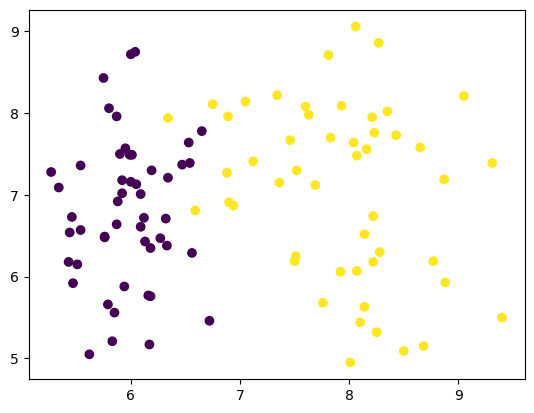

In [6]:
plt.scatter(df['cgpa'],df['resume_score'],c=df['placed'])

In [7]:
x = df.iloc[:,0:2]
y= df.iloc[:,-1]

In [8]:
x

,cgpa,resume_score
0,8.14,6.52
1,6.17,5.17
2,8.27,8.86
3,6.88,7.27
4,7.52,7.30
...,...,...
95,6.33,6.38
96,8.23,7.76
97,6.65,7.78
98,8.14,5.63


In [9]:
y

0     1
1     0
2     1
3     1
4     1
     ..
95    0
96    1
97    0
98    1
99    0
Name: placed, Length: 100, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train , x_test ,  y_train , y_test = train_test_split(x,y,test_size =0.15)

In [12]:
x_train

,cgpa,resume_score
83,7.60,8.08
15,8.88,5.93
32,5.87,7.96
91,8.28,6.30
28,7.46,7.67
...,...,...
63,8.65,7.58
70,7.12,7.41
17,7.81,8.71
37,9.05,8.21


In [13]:
x_test

,cgpa,resume_score
58,6.47,7.37
94,8.01,4.95
84,5.76,6.49
50,8.22,6.74
71,7.34,8.22
21,6.53,7.64
13,8.50,5.09
46,5.83,5.21
65,6.04,8.75
43,8.21,7.95


In [14]:
y_train

83    1
15    1
32    0
91    1
28    1
     ..
63    1
70    1
17    1
37    1
97    0
Name: placed, Length: 85, dtype: int64

In [15]:
y_test

58    0
94    1
84    0
50    1
71    1
21    0
13    1
46    0
65    0
43    1
42    1
1     0
74    0
8     0
55    1
Name: placed, dtype: int64

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

In [18]:
x_train = scaler.fit_transform(x_train)

In [19]:
x_train

array([[ 0.56366044,  1.19702092],
       [ 1.68767541, -1.10131459],
       [-0.95551603,  1.06874173],
       [ 1.16079339, -0.70578708],
       [ 0.44072131,  0.75873369],
       [-1.24530113, -0.4171589 ],
       [-0.92917193,  0.57700483],
       [-0.68329365, -0.65233742],
       [-0.54279178,  0.26699679],
       [-0.85013962,  0.5663149 ],
       [-0.91160919,  0.23492699],
       [ 0.47584678, -0.82337634],
       [-0.76232596,  0.05319814],
       [-0.18275574,  1.22909072],
       [ 2.14430648, -1.56098169],
       [-0.20909984, -1.60374142],
       [ 0.59000454,  1.0901216 ],
       [-0.55157315, -0.62026762],
       [-0.84135826,  0.21354712],
       [ 1.22226296,  1.13288133],
       [ 0.49340951,  0.36320618],
       [-1.31555207, -0.24611998],
       [ 0.97638469,  0.55562497],
       [ 0.76563188,  0.79080348],
       [-1.3331148 , -0.4492287 ],
       [-1.02576696, -1.38994277],
       [ 1.03785426, -1.42201256],
       [ 0.08068527,  1.26116052],
       [ 1.59108037,

In [20]:
x_test= scaler.fit_transform(x_test)

In [21]:
x_test

array([[-0.40064973,  0.52496776],
       [ 1.21453506, -1.56454207],
       [-1.14531285, -0.234854  ],
       [ 1.43478753, -0.01899554],
       [ 0.51182479,  1.2588865 ],
       [-0.33772046,  0.75809489],
       [ 1.72845749, -1.44366133],
       [-1.07189536, -1.34004927],
       [-0.85164289,  1.71650642],
       [ 1.42429932,  1.02575937],
       [ 0.05034342,  0.1277882 ],
       [-0.71529612, -1.37458663],
       [-1.37605354,  0.51633342],
       [-0.55797293, -0.04489856],
       [ 0.09229627,  0.09325085]])

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
clf = LogisticRegression()

In [24]:
# model training

clf.fit(x_train,y_train)

LogisticRegression()

In [25]:
y_pred = clf.predict(x_test)

In [26]:
y_test

58    0
94    1
84    0
50    1
71    1
21    0
13    1
46    0
65    0
43    1
42    1
1     0
74    0
8     0
55    1
Name: placed, dtype: int64

In [27]:
from sklearn.metrics import accuracy_score


In [28]:
accuracy_score(y_test,y_pred)

1.0

In [29]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

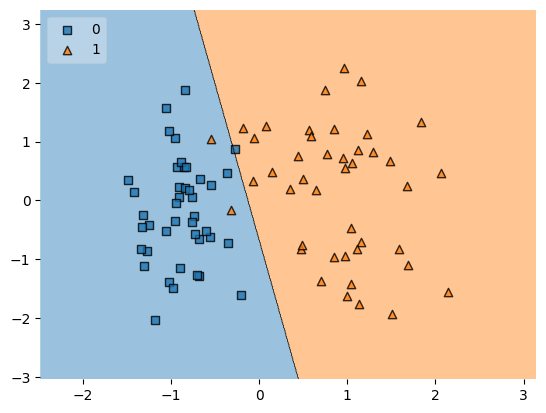

In [30]:
plot_decision_regions( x_train ,y_train.values , clf= clf , legend = 2)